# Multinomial Naive bayes

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importing the dataset

In [9]:
df=pd.read_csv("spam.csv",encoding="latin-1")

In [10]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [13]:
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)

In [14]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Exploratory Data Analysis

In [15]:
df.duplicated().sum()

403

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape

(5169, 2)

# EDA

In [18]:
df['Target'].value_counts()

Target
ham     4516
spam     653
Name: count, dtype: int64

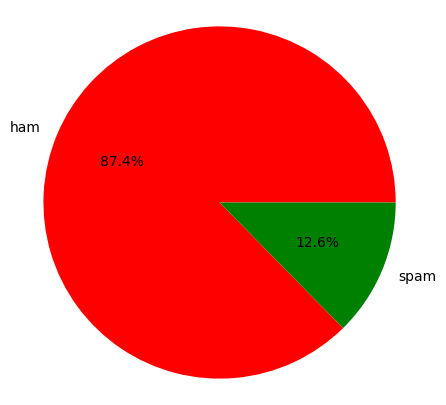

In [19]:
plt.figure(figsize=(5,5))
plt.pie(df["Target"].value_counts(),labels=['ham','spam'],autopct="%1.1f%%",colors=['red','green'])
plt.axis("equal")
plt.show()

In [20]:
df['Char_count']=df["Text"].apply(len)

In [21]:
df

,Target,Text,Char_count
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [22]:
#for spam messages
df[df['Target']=='spam']['Char_count'].describe()

count    653.000000
mean     137.891271
std       30.137753
min       13.000000
25%      132.000000
50%      149.000000
75%      157.000000
max      224.000000
Name: Char_count, dtype: float64

In [23]:
#for non spam messages
df[df['Target']=='ham']['Char_count'].describe()

count    4516.000000
mean       70.459256
std        56.358207
min         2.000000
25%        34.000000
50%        52.000000
75%        90.000000
max       910.000000
Name: Char_count, dtype: float64

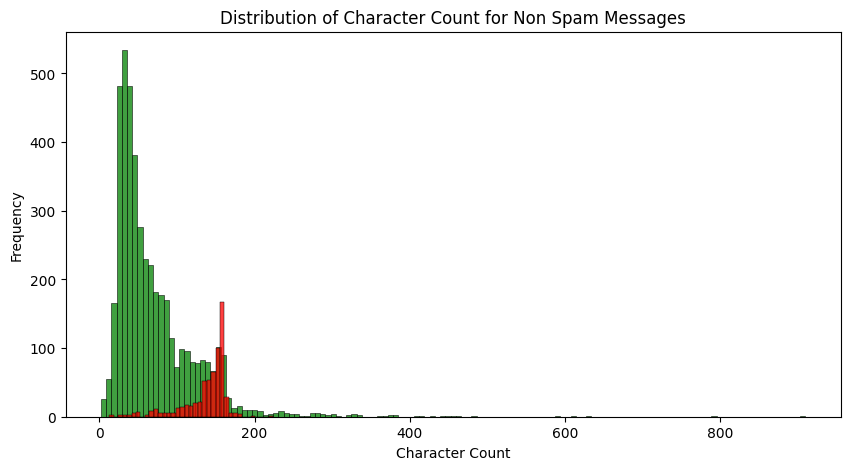

In [24]:
#histogram for non spam messages
plt.figure(figsize=(10,5))
sns.histplot(df[df['Target']=='ham']['Char_count'],color='green')
sns.histplot(df[df['Target']=='spam']['Char_count'],color='red')
plt.xlabel('Character Count')
plt.ylabel("Frequency")
plt.title("Distribution of Character Count for Non Spam Messages")
plt.show()

In [25]:
from wordcloud import WordCloud

In [26]:
#for non spam messages
ham_mess_text=df[df['Target']=='ham']['Text']
ham_mess_text

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
6       Even my brother is not like to speak with me. ...
                              ...                        
5565                                         Huh y lei...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Text, Length: 4516, dtype: object

In [27]:
#for spam messages
spam_mess_text=df[df['Target']=='spam']['Text']
spam_mess_text

2       Free entry in 2 a wkly comp to win FA Cup fina...
5       FreeMsg Hey there darling it's been 3 week's n...
8       WINNER!! As a valued network customer you have...
9       Had your mobile 11 months or more? U R entitle...
11      SIX chances to win CASH! From 100 to 20,000 po...
                              ...                        
5537    Want explicit SEX in 30 secs? Ring 02073162414...
5540    ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547    Had your contract mobile 11 Mnths? Latest Moto...
5566    REMINDER FROM O2: To get 2.50 pounds free call...
5567    This is the 2nd time we have tried 2 contact u...
Name: Text, Length: 653, dtype: object

# Word Cloud

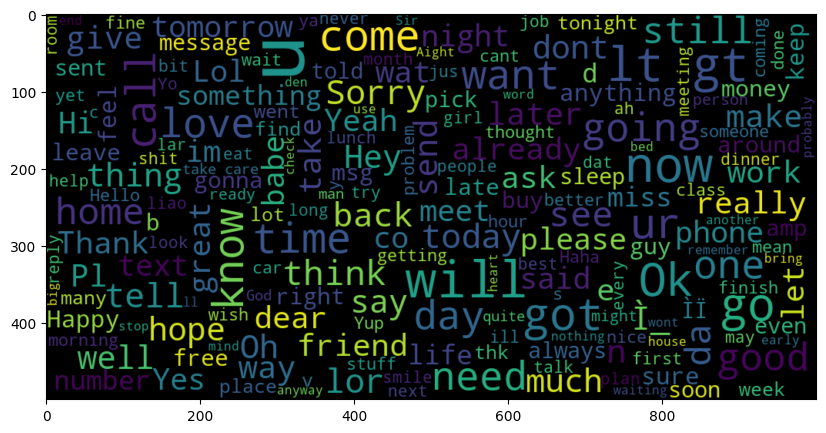

In [28]:
plt.figure(figsize=(10,5))
wordcloud=WordCloud(width=1000,height=500,max_font_size=100).generate(" ".join(ham_mess_text))
plt.imshow(wordcloud,interpolation='bilinear')

This graph shows the most common keywords in ham message

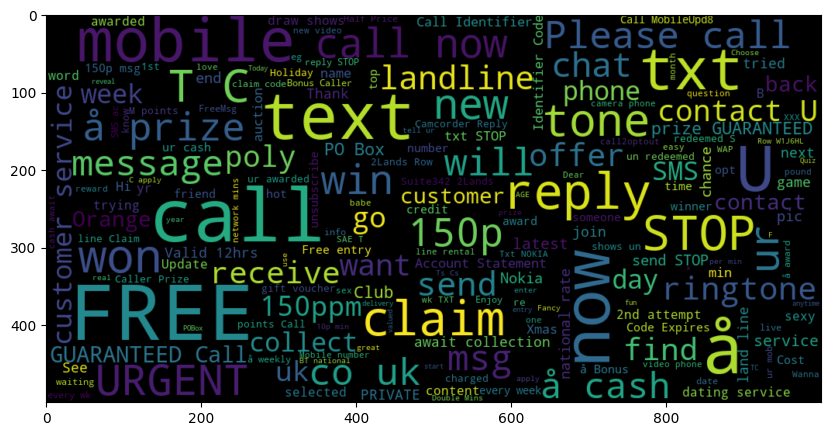

In [29]:
plt.figure(figsize=(10,6))
wordcloud= WordCloud(width=1000,height=500,max_font_size=100).generate(" ".join(spam_mess_text))
plt.imshow(wordcloud,interpolation='bilinear')

This shows the most common text in the spam message

# Data Cleaning and Preprocessing

In [30]:
df['Text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [31]:
import string
import re

In [32]:
#Remove Punctuation
def remove_punctuation(Text):
    Text=Text.translate(str.maketrans('','',string.punctuation))
    return Text

In [33]:
df['Text']=df["Text"].apply(remove_punctuation)

In [34]:
df['Text'][9]

'Had your mobile 11 months or more U R entitled to Update to the latest colour mobiles with camera for Free Call The Mobile Update Co FREE on 08002986030'

In [35]:
# remove special charcaters
def remove_special_characters(Text):
    Text=re.sub(r'[^a-zA-Z\s+]',' ',Text)
    return Text

In [36]:
df['Text']=df['Text'].apply(remove_special_characters)

In [37]:
df['Text'][8]

'WINNER As a valued network customer you have been selected to receivea       prize reward To claim call             Claim code KL    Valid    hours only'

In [40]:
import nltk
nltk.download('stopwords')

sw = stopwords.words('english')
len(sw)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91736\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


198

In [41]:
def remove_stopwords(Text):
    Text=" ".join([word for word in Text.split() if word.lower() not in sw])
    return Text

In [43]:
df['Text']=df['Text'].apply(remove_stopwords)

In [44]:
df['Text'][8]

'WINNER valued network customer selected receivea prize reward claim call Claim code KL Valid hours'

In [45]:
#convert text to lower case
def covert_lower_case(Text):
    Text=Text.lower()
    return Text

In [46]:
df['Text']=df['Text'].apply(covert_lower_case)

In [47]:
df['Text'][8]

'winner valued network customer selected receivea prize reward claim call claim code kl valid hours'

In [48]:
df.head()

,Target,Text,Char_count
0,ham,go jurong point crazy available bugis n great ...,111
1,ham,ok lar joking wif u oni,29
2,spam,free entry wkly comp win fa cup final tkts st ...,155
3,ham,u dun say early hor u c already say,49
4,ham,nah dont think goes usf lives around though,61


In [49]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [50]:
df['Target']=le.fit_transform(df['Target'])

In [51]:
df.head()

,Target,Text,Char_count
0,0,go jurong point crazy available bugis n great ...,111
1,0,ok lar joking wif u oni,29
2,1,free entry wkly comp win fa cup final tkts st ...,155
3,0,u dun say early hor u c already say,49
4,0,nah dont think goes usf lives around though,61


# Feature Extraction

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(max_features=3000)

In [55]:
X=tf.fit_transform(df['Text']).toarray()
y=df['Target']

In [56]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [57]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Target, Length: 5169, dtype: int32

# Model Building & Evaluation

In [60]:
#split the data into training and testing
from ctypes.util import test

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)  

In [62]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((4135, 3000), (4135,), (1034, 3000), (1034,))

In [63]:
# Model Building
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()

In [64]:
model.fit(X_train,y_train)

MultinomialNB()

In [66]:
#make a prediction on test data
y_pred=model.predict(X_test)

In [67]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

# Model Evaluation

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.82      0.90       145

    accuracy                           0.97      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.97      0.97      1034

Confusion Matrix:
[[889   0]
 [ 26 119]]
Accuracy Score: 97.48549323017409


In [71]:
#accuracy score
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100)

Accuracy Score: 97.48549323017409


In [73]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix:
[[889   0]
 [ 26 119]]


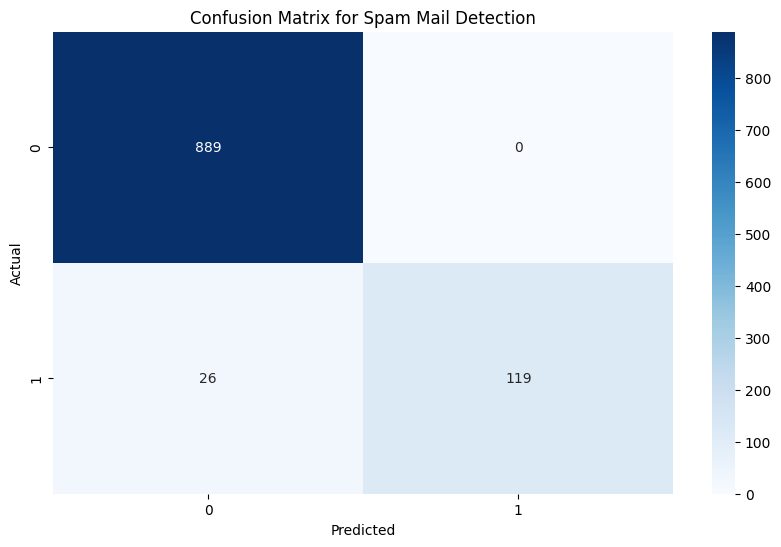

In [76]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix for Spam Mail Detection")
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()